Installing the spectral library for reading the **.qub** and **.hdr** files

In [1]:
! pip install spectral

import spectral
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten , MaxPooling2D

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 6.3 MB/s eta 0:00:00


Mount the Gdrive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Specifying the files path to variables

In [3]:
data_file = "/content/drive/MyDrive/IIRS/hyperspectral_image.qub"
header_file = "/content/drive/MyDrive/IIRS/image_metadata.hdr"
geometry_file = "/content/drive/MyDrive/IIRS/geolocation_data.csv"

Reading the data

In [4]:
data = spectral.io.envi.open(header_file, image=data_file)
hyperspectral_data = data.load()
print(f"Shape of the data: {hyperspectral_data.shape}")

Shape of the data: (1521, 250, 256)


Saving the plots using custom `save_fig()` function

In [5]:
IMAGES_PATH = Path() / "images" / "hyperspectral"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Plot of reflectance variation
The `plot_reflectance_variation(x, y)` below plots the reflectance values with respect to the wavelength at the coordinates specified by the user.
*Coordinates must be in the range of (250 , 9340)*

In [6]:
def plot_reflectance_variation(x , y):
  if x >= 0 and x < hyperspectral_data.shape[1] and y >= 0 and y < hyperspectral_data.shape[0]:
    reflectance_values = hyperspectral_data[y, x, :]
    plt.figure(figsize = (10 , 6))
    plt.plot(range(hyperspectral_data.shape[2]), reflectance_values.squeeze())
    plt.xlabel('Wavelength')
    plt.ylabel('Reflectance')
    plt.title(f'Reflectance Variation at ({x}, {y})')
    save_fig("reflectance variation vs wavelength")
    plt.show()
  else:
    print("Invalid coordinates")

Enter the x coordinate: 125
Enter the y coordinate: 100


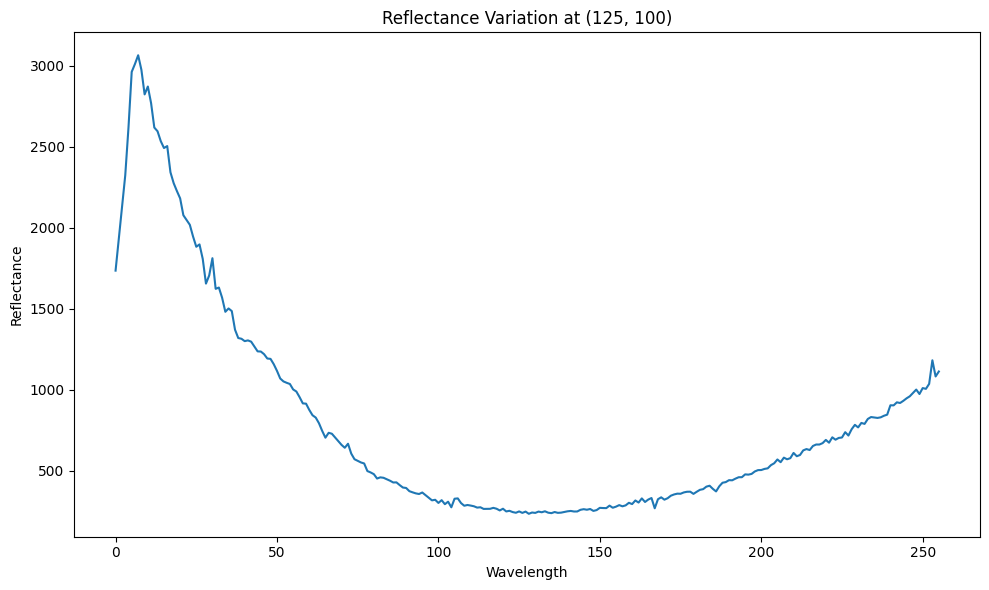

In [7]:
x = int(input("Enter the x coordinate: "))
y = int(input("Enter the y coordinate: "))
plot_reflectance_variation(x , y)

Plotting the grayscale image of the 9340 x 250 region at 6 different wavelength (bands -  10 , 50 , 100 , 150 , 200 , 256)

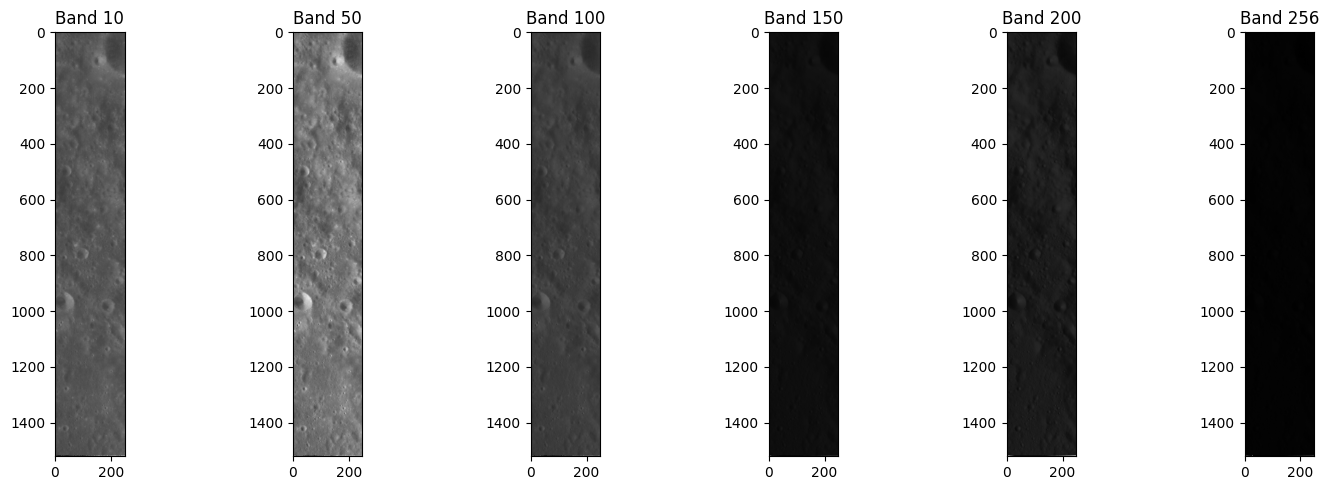

In [8]:
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

axes[0].imshow(hyperspectral_data[:,:,10], cmap='gray')
axes[0].set_title('Band 10')

axes[1].imshow(hyperspectral_data[:,:,50], cmap='gray')
axes[1].set_title('Band 50')

axes[2].imshow(hyperspectral_data[:,:,100], cmap='gray')
axes[2].set_title('Band 100')

axes[3].imshow(hyperspectral_data[:,:,150], cmap='gray')
axes[3].set_title('Band 150')

axes[4].imshow(hyperspectral_data[:,:,200], cmap='gray')
axes[4].set_title('Band 200')

axes[5].imshow(hyperspectral_data[:,:,255], cmap='gray')
axes[5].set_title('Band 256')

save_fig("grayscale image of strip at 6 different bands")

plt.show()

# Plot of moon surface with region of interest along with geographical coordinates at a specific band

In [9]:
coord_df = pd.read_csv(geometry_file)

In [10]:
coord_df.head()

,Longitude,Latitude,Pixel,Scan
0,146.275991,12.350115,0,0
1,146.418392,12.347578,50,0
2,146.560712,12.344941,100,0
3,146.702993,12.342201,150,0
4,146.845278,12.339360,200,0


Enter the band: 125


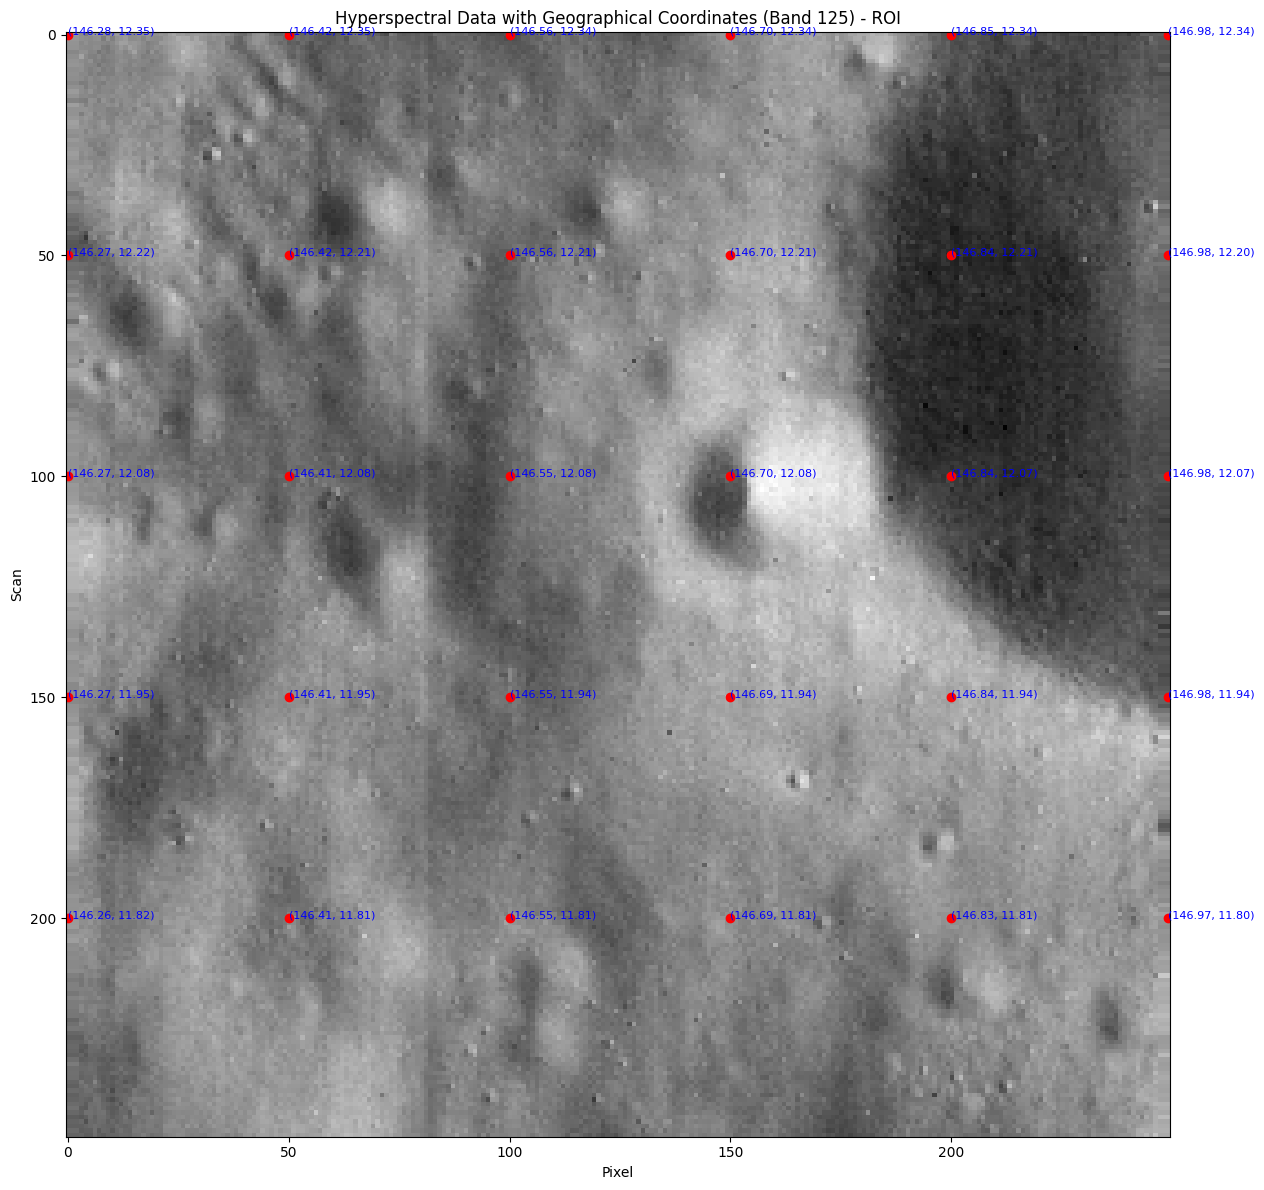

In [11]:
# roi = region of interest
roi_start_x = 0
roi_end_x = 250
roi_start_y = 0
roi_end_y = 250

def plot_roi_hyperspectral_with_coords(band_index):
    plt.figure(figsize=(20, 12))

    plt.imshow(hyperspectral_data[roi_start_y:roi_end_y, roi_start_x:roi_end_x, band_index], cmap='gray')

    for index, row in coord_df.iterrows():
        pixel = row['Pixel']
        scan = row['Scan']


        if roi_start_x <= pixel < roi_end_x and roi_start_y <= scan < roi_end_y:
            lon = row['Longitude']
            lat = row['Latitude']


            plt.plot(pixel - roi_start_x, scan - roi_start_y, 'ro')
            plt.text(pixel - roi_start_x, scan - roi_start_y, f"({lon:.2f}, {lat:.2f})", color='blue', fontsize=8)

    plt.title(f'Hyperspectral Data with Geographical Coordinates (Band {band_index}) - ROI')
    plt.xlabel('Pixel')
    plt.ylabel('Scan')
    save_fig(f"Image geographical coordinates")
    plt.show()

plot_roi_hyperspectral_with_coords(int(input(f"Enter the band: ")))

# Data Preparation
* Reshaping
* Normalization
* PCA

Normalizing the data by dividing each reflectance value by the maximum reflectance value . In order to achieve values between 0-1. This will improve the traning time of the ml models.

In [12]:
normalized_data = hyperspectral_data / np.max(hyperspectral_data)

/tmp/ipykernel_1863/2790604798.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized_data = hyperspectral_data / np.max(hyperspectral_data)


Reducing the dimention of the data to 2-dimentions

In [13]:
flattened_data = normalized_data.reshape(-1, normalized_data.shape[-1])

In [14]:
flattened_data.shape

(380250, 256)

In [15]:
print(flattened_data[:10])

[[0.00622076 0.00667409 0.00712743 ... 0.00308375 0.00287057 0.00295244]
 [0.00622076 0.00667409 0.00712743 ... 0.00308375 0.00287057 0.00295244]
 [0.00622076 0.00667409 0.00712743 ... 0.00308375 0.00287057 0.00295244]
 ...
 [0.00576955 0.00585054 0.00593153 ... 0.00332213 0.00325173 0.00342796]
 [0.00444085 0.0047199  0.00499894 ... 0.00339197 0.00298064 0.00302577]
 [0.0038356  0.00437755 0.0049195  ... 0.00350411 0.00310666 0.00323648]]


# Dimensionality Reduction using Principal component analysis

* PCA can further reduce the dimensionality by keeping the most important components, making it more manageable for clustering and CNN processing.
* As you can see the 10 principal components capture 98.31% of the variability in your original hyperspectral data

In [16]:
pca = PCA(n_components = 10)
reduced_data = pca.fit_transform(flattened_data)

explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Explained Variance Ratio by 10 components: {explained_variance}")

Explained Variance Ratio by 10 components: 0.9599847793579102


In [17]:
reduced_data.shape

(380250, 10)

# Clustering

* Applying **k-mean clustering**

Applying k-mean to seperate the data into 5 different clusters . We will use these clusters as labels for classification.

In [18]:
kmean = KMeans(n_clusters=5)

In [19]:
labels = kmean.fit_predict(reduced_data)

In [20]:
def nearest_centroid(X , centroid):
  k = centroid.shape[0]
  c = np.zeros(X.shape[0] , dtype=int)

  for i in range(X.shape[0]):
    distance = []
    for j in range(k):
      norm_ij = np.linalg.norm(X[i] - centroid[j])
      distance.append(norm_ij)
    c[i] = np.argmin(distance)
  return c

def compute_centroid(X , c , k):
  m , n = X.shape
  centroids = np.zeros((k , n))
  for i in range(k):
    centroids[i] = np.mean(X[c == i] , axis = 0)
  return centroids

def initialize_centroid(X , k):
  random_index = np.random.permutation(X.shape[0])
  return X[random_index[:k]]

In [21]:
# Inspect sklearn KMeans results instead of removed manual KMeans
kmean.cluster_centers_, labels.shape, kmean.cluster_centers_.shape


(array([[ 5.66461962e-03, -5.21260547e-03, -1.29115721e-03,
         -3.12322692e-04,  6.64905965e-05, -7.07025683e-05,
          5.79034095e-05, -7.16396880e-06, -9.62914492e-05,
         -1.06549624e-05],
        [-4.20878874e-03,  4.04951163e-03, -1.18838159e-06,
          2.91797012e-04,  4.39170617e-05,  7.80304108e-05,
         -9.73632486e-05,  1.03606748e-04,  1.54962807e-04,
          6.66588676e-05],
        [-1.57118286e-03, -1.66640943e-03,  7.85165525e-04,
         -3.66001586e-05, -6.98065778e-05, -2.10851140e-05,
          3.27827875e-05, -5.58655156e-05, -3.89070374e-05,
         -4.08566484e-05],
        [ 2.52629727e-01,  4.22073752e-02,  3.72032486e-02,
          8.59067403e-03, -2.57253088e-03,  7.63547421e-03,
         -8.28398950e-03,  4.36525326e-03,  1.16547402e-02,
         -1.74144661e-05],
        [ 2.13401415e-03,  1.52319192e-03, -2.58792512e-04,
         -3.25799519e-05,  1.25426695e-05, -5.76699995e-06,
          1.55502912e-05, -1.85196441e-05, -3.767129

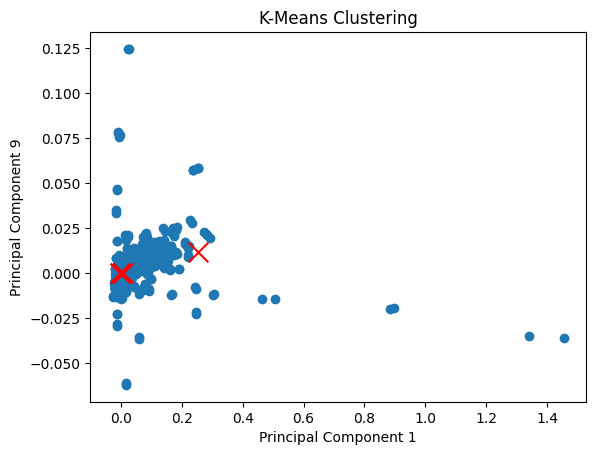

In [22]:
plt.scatter(reduced_data[:, 0], reduced_data[:, 8])
plt.scatter(kmean.cluster_centers_[:, 0], kmean.cluster_centers_[:, 8], marker='x', color='red', s=200)
plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 9")
plt.show()

In [23]:
clustered_image = labels.reshape(hyperspectral_data.shape[0] , hyperspectral_data.shape[1])

In [24]:
labels.shape

(380250,)

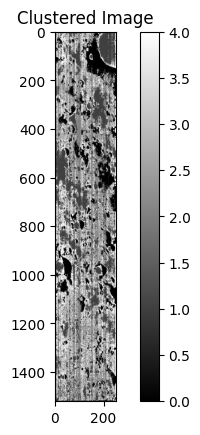

In [25]:
plt.imshow(clustered_image, cmap='gray')
plt.title("Clustered Image")
plt.colorbar()
plt.show()

# Classification
* CNN

Splitting the data into traning and test sets.

In [26]:
X = reduced_data
y = labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train.shape

(304200, 10)

* Defining the input shape of the data to the CNN Model.
* Then building the structure of the CNN model.

In [28]:
X_train_cnn = X_train.reshape(-1, 10, 1, 1)
X_test_cnn = X_test.reshape(-1, 10, 1, 1)

In [29]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(10 ,1,1) ,  padding='same'),
    MaxPooling2D((2, 1)),
    Conv2D(64, (3, 3), activation='relu',  padding='same'),
    MaxPooling2D((2, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 10, 1, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 1, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 1, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,325 (251.27 KB)

 Trainable params: 64,325 (251.27 KB)

 Non-trainable params: 0 (0.00 B)

Then compiling and fitting the model

In [31]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.8275 - loss: 0.3805 - val_accuracy: 0.9652 - val_loss: 0.0888
Epoch 2/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9731 - loss: 0.0657 - val_accuracy: 0.9716 - val_loss: 0.0663
Epoch 3/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.9781 - loss: 0.0531 - val_accuracy: 0.9777 - val_loss: 0.0526
Epoch 4/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9803 - loss: 0.0478 - val_accuracy: 0.9802 - val_loss: 0.0485
Epoch 5/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9814 - loss: 0.0449 - val_accuracy: 0.9835 - val_loss: 0.0394
Epoch 6/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9828 - loss: 0.0412 - val_accuracy: 0.9835 - val_loss: 0.0394
Epoch 7/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9827 - loss: 0.0417 - val_accuracy: 0.9761 - val_loss: 0.0549
Epoch 8/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9818 - loss: 0

In [32]:
cnn_eval = cnn_model.evaluate(X_test_cnn, y_test)
print(f'CNN Accuracy: {cnn_eval[1]}')

2377/2377 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9866 - loss: 0.0348
CNN Accuracy: 0.9866403937339783


ON TEST SET OUR MODEL IS GIVING ACCURACY OF MORE THAN 98%

In [34]:
# 1. Apply the trained CNN model to the entire dataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd


In [35]:
# Reshape the full PCA-reduced data for prediction
print("Reshaping data for prediction...")
full_data_cnn = reduced_data.reshape(-1, 10, 1, 1)

# Generate predictions
print("Generating predictions with CNN model...")
predicted_probabilities = cnn_model.predict(full_data_cnn)
predicted_labels = np.argmax(predicted_probabilities, axis=1)

# Reshape back to original image dimensions
classified_image = predicted_labels.reshape(hyperspectral_data.shape[0], hyperspectral_data.shape[1])


Reshaping data for prediction...
Generating predictions with CNN model...
11883/11883 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step


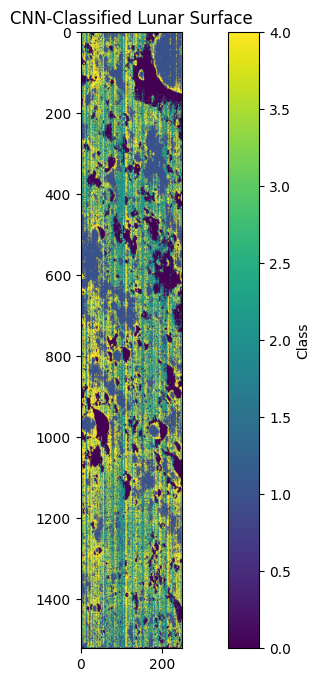

In [36]:
plt.figure(figsize=(12, 8))
plt.imshow(classified_image, cmap='viridis')
plt.title("CNN-Classified Lunar Surface")
plt.colorbar(label="Class")
plt.show()

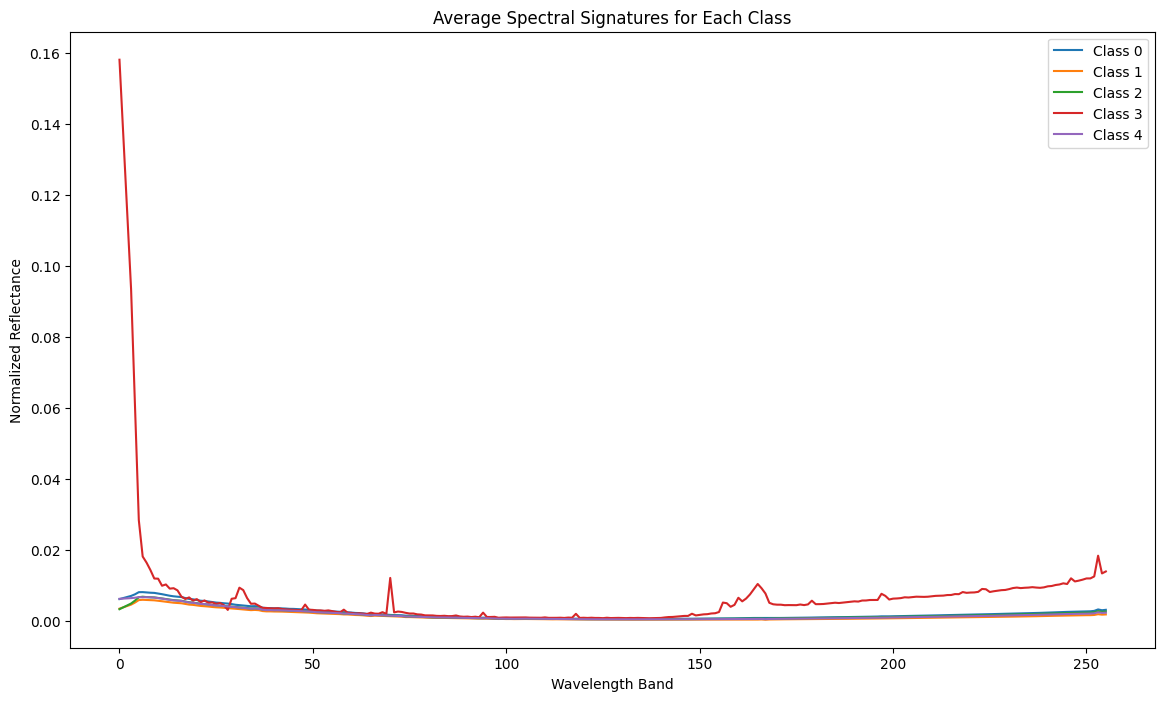

In [37]:
# Extract average spectra for each class
class_spectra = []
for i in range(5):
    class_mask = (predicted_labels == i)
    avg_spectrum = np.mean(flattened_data[class_mask], axis=0)
    class_spectra.append(avg_spectrum)

# Plot average spectra for each class
plt.figure(figsize=(14, 8))
for i, spectrum in enumerate(class_spectra):
    plt.plot(range(256), spectrum, label=f"Class {i}")
plt.title("Average Spectral Signatures for Each Class")
plt.xlabel("Wavelength Band")
plt.ylabel("Normalized Reflectance")
plt.legend()
plt.show()

Visualizing the final classified lunar surface...


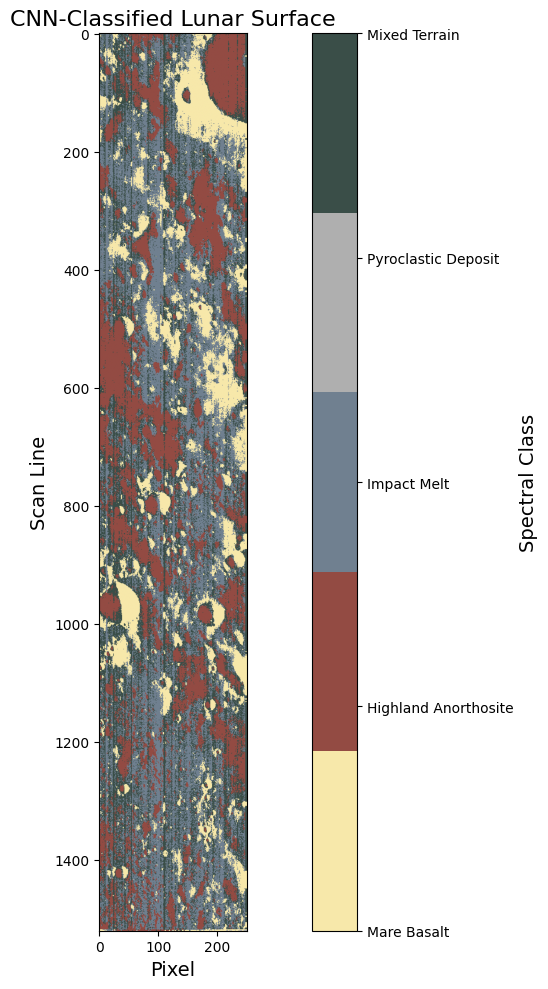

In [38]:
# 2. Visualize the final classified image
print("Visualizing the final classified lunar surface...")
lunar_cmap = ListedColormap(['#f7e8aa', '#934b43', '#708090', '#afafaf', '#3a4e48'])

plt.figure(figsize=(14, 10))
plt.imshow(classified_image, cmap=lunar_cmap)
plt.title("CNN-Classified Lunar Surface", fontsize=16)
cbar = plt.colorbar(ticks=range(5))
cbar.set_label("Spectral Class", fontsize=14)
cbar.set_ticklabels(['Mare Basalt', 'Highland Anorthosite', 'Impact Melt', 'Pyroclastic Deposit', 'Mixed Terrain'])
plt.xlabel("Pixel", fontsize=14)
plt.ylabel("Scan Line", fontsize=14)
save_fig("cnn_classified_lunar_surface")
plt.show()


In [39]:
# 3. Extract and analyze average spectral signatures for each class
print("Extracting spectral signatures for each class...")
class_spectra = []
class_names = ['Mare Basalt', 'Highland Anorthosite', 'Impact Melt', 'Pyroclastic Deposit', 'Mixed Terrain']
class_colors = ['#f7e8aa', '#934b43', '#708090', '#afafaf', '#3a4e48']

for i in range(5):
    class_mask = (predicted_labels == i)
    if np.any(class_mask):  # Check if there are any pixels with this class
        avg_spectrum = np.mean(flattened_data[class_mask], axis=0)
        class_spectra.append(avg_spectrum)
    else:
        print(f"Warning: No pixels found for Class {i}")
        class_spectra.append(np.zeros(flattened_data.shape[1]))


Extracting spectral signatures for each class...


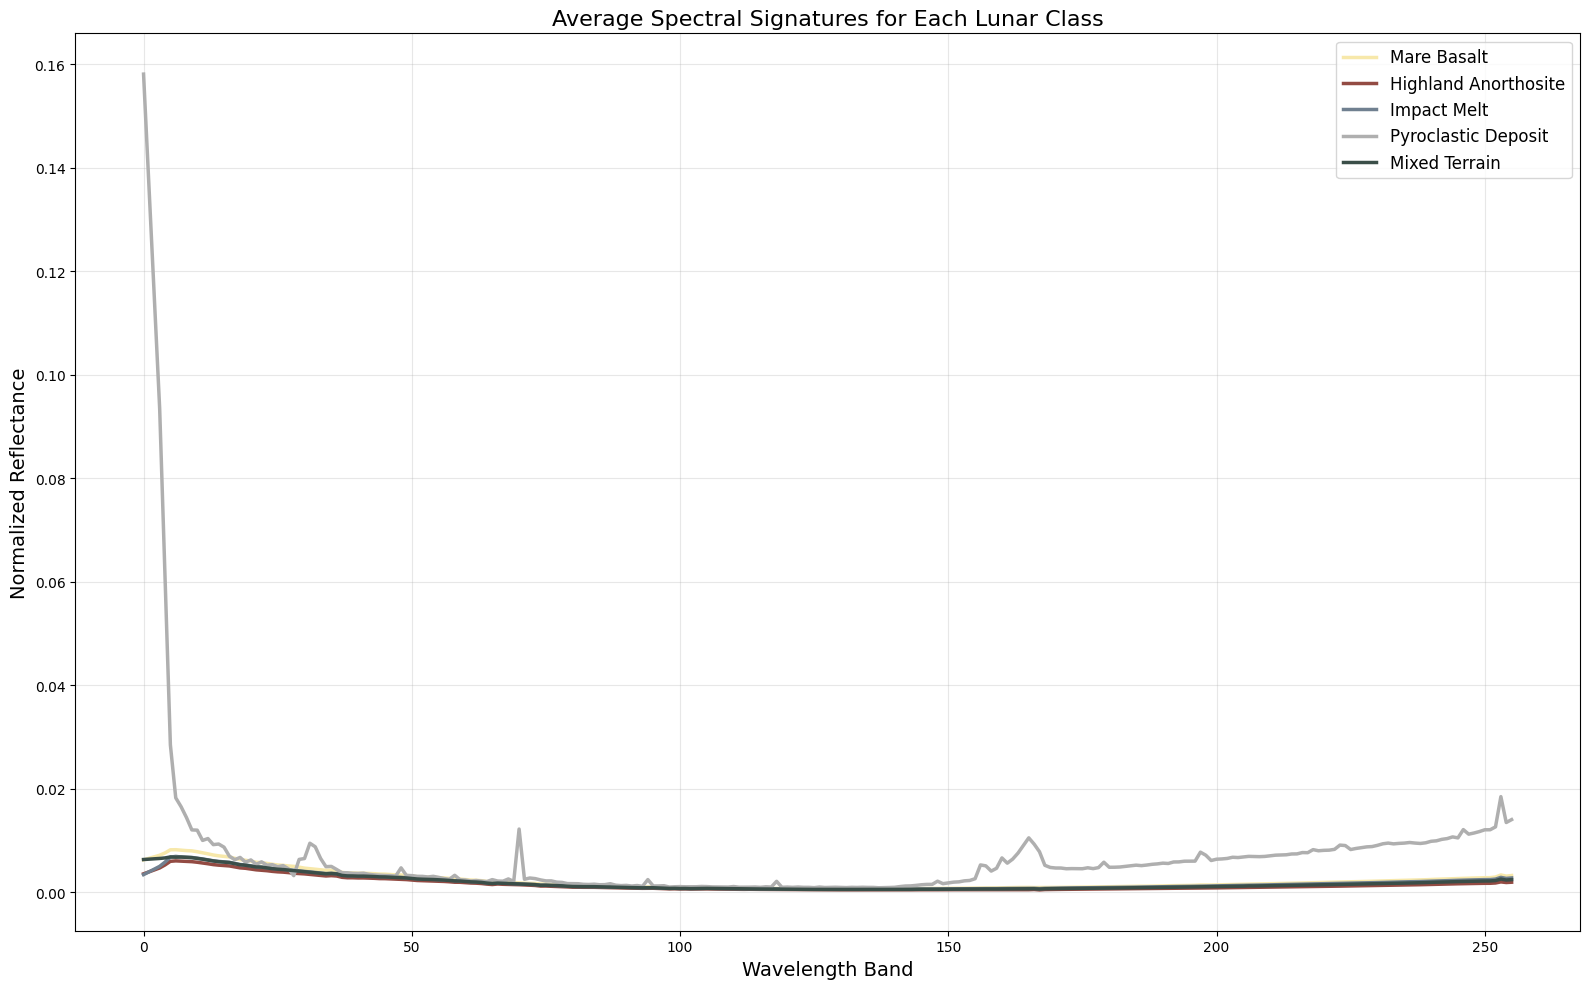

In [40]:

# 4. Plot average spectral signatures
plt.figure(figsize=(16, 10))
for i, spectrum in enumerate(class_spectra):
    plt.plot(range(hyperspectral_data.shape[2]), spectrum, label=class_names[i],
             linewidth=2.5, color=class_colors[i])

plt.title("Average Spectral Signatures for Each Lunar Class", fontsize=16)
plt.xlabel("Wavelength Band", fontsize=14)
plt.ylabel("Normalized Reflectance", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
save_fig("class_spectral_signatures")
plt.show()

In [41]:
# 5. Calculate class distribution
class_counts = np.bincount(predicted_labels, minlength=5)
class_percentages = class_counts / len(predicted_labels) * 100

# Create a DataFrame for better presentation
class_df = pd.DataFrame({
    'Class': class_names,
    'Count': class_counts,
    'Percentage': class_percentages
})

print("\nClass Distribution in the Classified Image:")
print(class_df)



Class Distribution in the Classified Image:
                  Class   Count  Percentage
0           Mare Basalt   57741   15.185010
1  Highland Anorthosite   88282   23.216831
2           Impact Melt  130276   34.260618
3   Pyroclastic Deposit      70    0.018409
4         Mixed Terrain  103881   27.319132


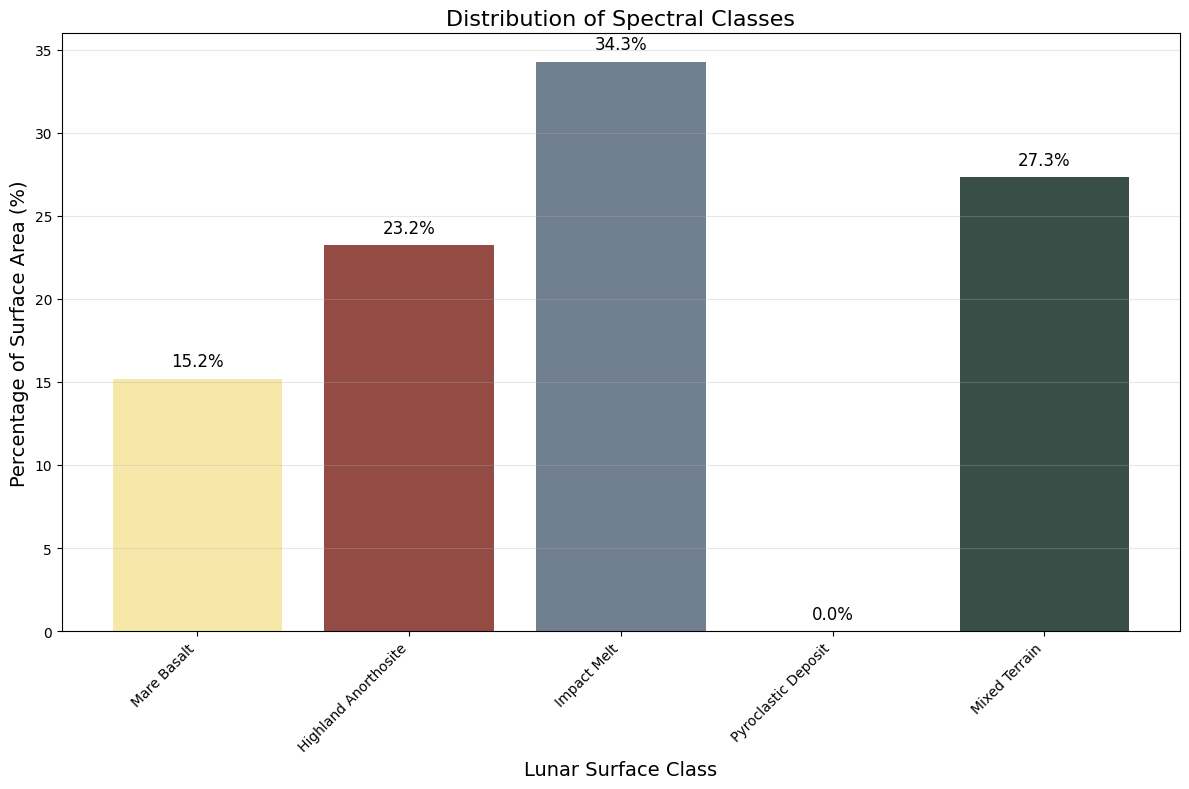

In [42]:
# 6. Visualize class distribution
plt.figure(figsize=(12, 8))
bars = plt.bar(class_names, class_percentages, color=class_colors)
plt.title("Distribution of Spectral Classes", fontsize=16)
plt.xlabel("Lunar Surface Class", fontsize=14)
plt.ylabel("Percentage of Surface Area (%)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
save_fig("class_distribution")
plt.show()

Wavelength range: 800.0 nm  →  5000.0 nm


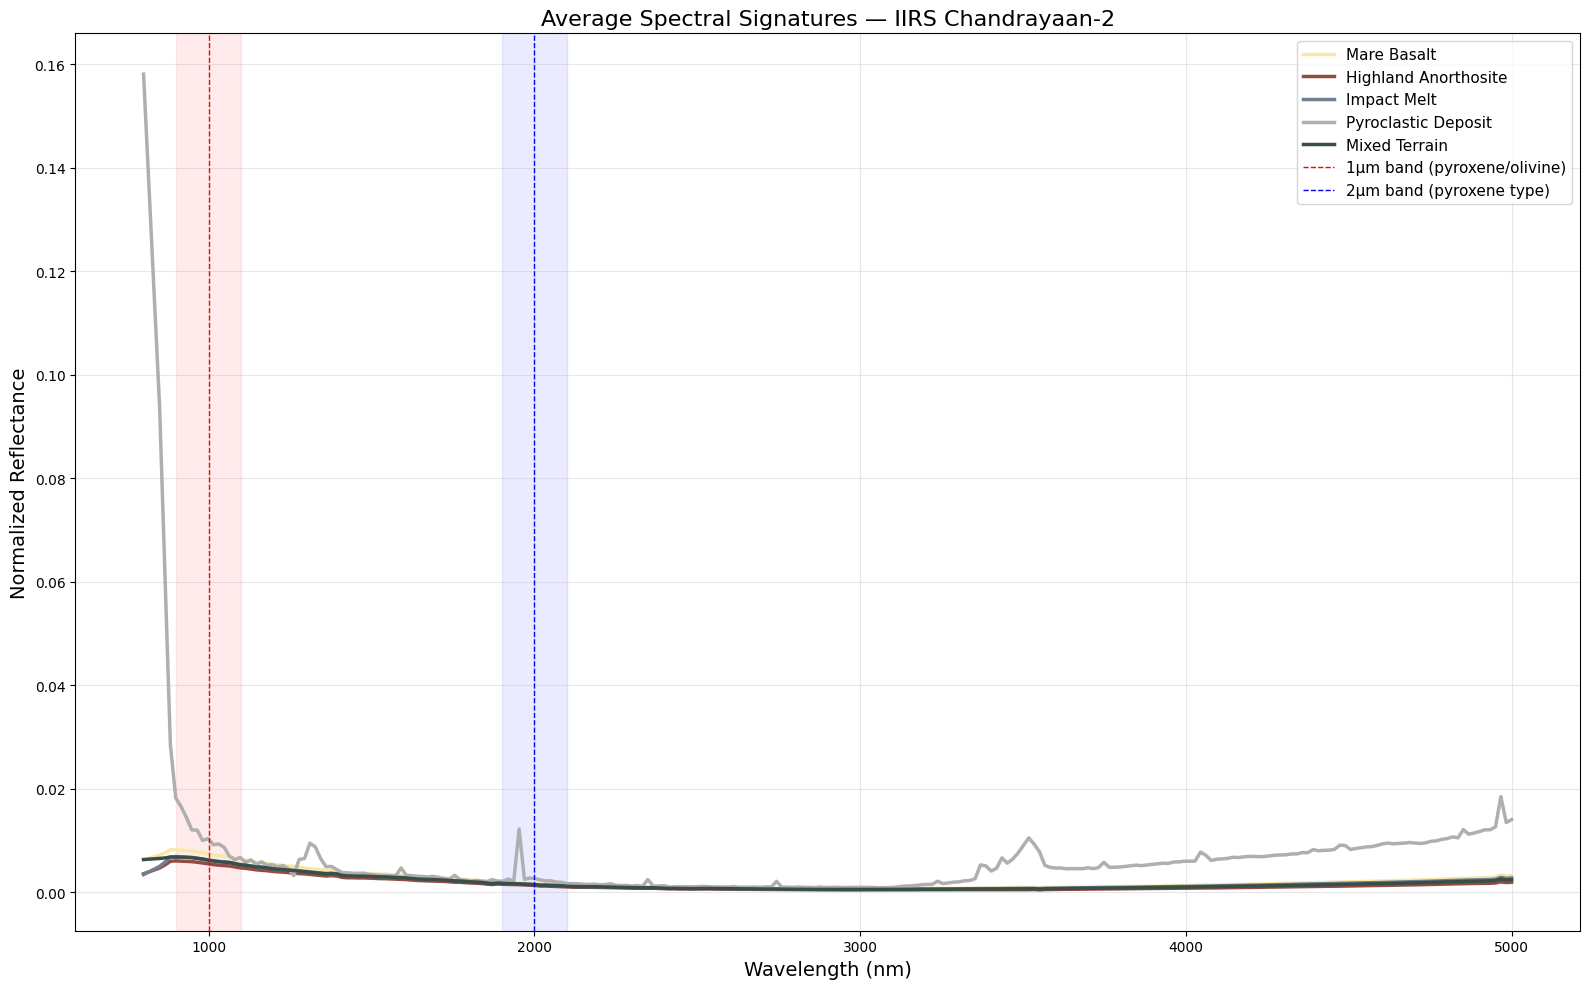

In [43]:
# ── CELL A: Real wavelength axis ─────────────────────────────────────────────

# IIRS instrument wavelength range: 800nm to 5000nm across 256 bands
wavelengths = np.linspace(800, 5000, hyperspectral_data.shape[2])
print(f"Wavelength range: {wavelengths[0]:.1f} nm  →  {wavelengths[-1]:.1f} nm")
# Re-plot spectral signatures with ACTUAL wavelengths on X-axis
plt.figure(figsize=(16, 10))

for i, spectrum in enumerate(class_spectra):
    plt.plot(wavelengths, spectrum,
             label=class_names[i], linewidth=2.5, color=class_colors[i])

# Highlight the two diagnostic absorption windows
plt.axvspan(900, 1100, alpha=0.08, color='red')
plt.axvline(1000, color='red', linestyle='--', linewidth=1, label='1µm band (pyroxene/olivine)')

plt.axvspan(1900, 2100, alpha=0.08, color='blue')
plt.axvline(2000, color='blue', linestyle='--', linewidth=1, label='2µm band (pyroxene type)')

plt.title("Average Spectral Signatures — IIRS Chandrayaan-2", fontsize=16)
plt.xlabel("Wavelength (nm)", fontsize=14)
plt.ylabel("Normalized Reflectance", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("spectral_signatures_with_wavelengths")
plt.show()

Class                       BD_1µm   BD_2µm  Slope_VIS  Interpretation
--------------------------------------------------------------------------------
Mare Basalt                -0.3218   0.2229  -0.000003  ✓ Featureless + flat — Mixed Terrain / immature regolith
Highland Anorthosite       -0.5497   0.2037  -0.000000  ✓ Featureless + flat — Mixed Terrain / immature regolith
Impact Melt                -0.7181   0.2119   0.000001  ✓ Featureless + red slope — consistent with Highland Anorthosite
Pyroclastic Deposit         0.8936  -0.1595  -0.000307  ✓ Olivine-dominated — could be Pyroclastic or Impact Melt
Mixed Terrain              -0.1533   0.2105  -0.000005  ✓ Featureless + flat — Mixed Terrain / immature regolith


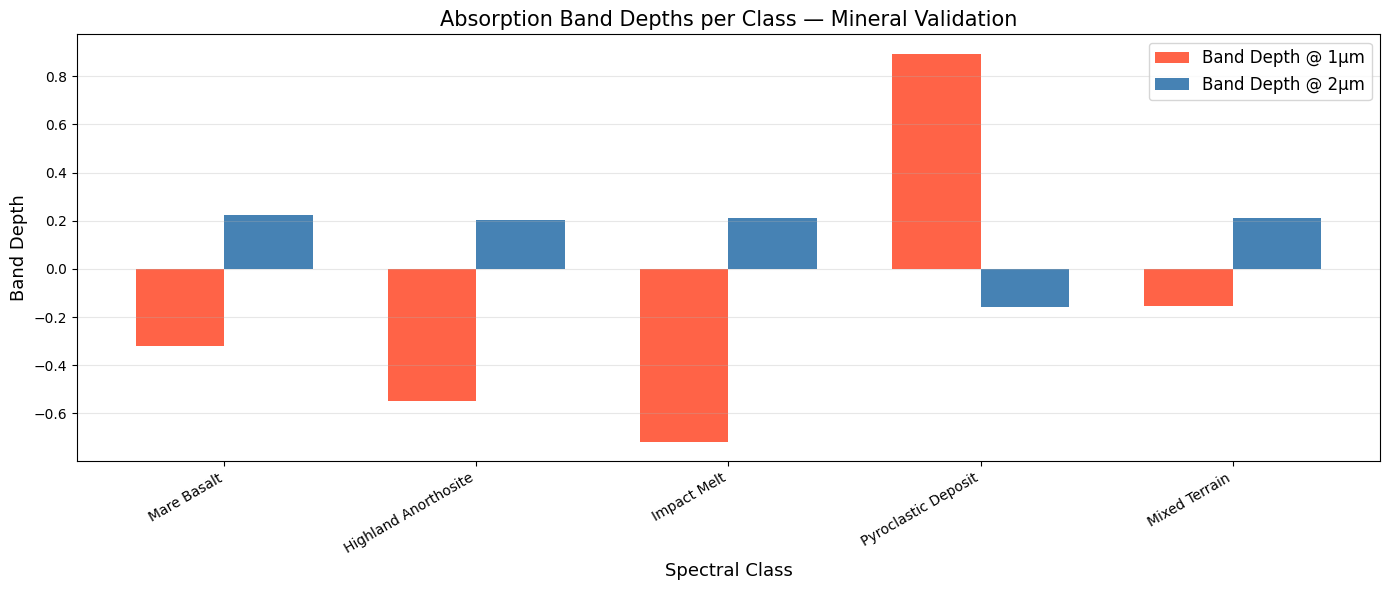


── Reference (what the numbers mean) ────────────────────────────────────
BD_1µm > 0.05  →  mafic mineral absorption (pyroxene / olivine present)
BD_2µm > 0.05  →  pyroxene confirmed (LCP/HCP)
BD_1µm < 0.02  →  plagioclase-rich / anorthosite / spectrally flat terrain
Slope > 0      →  red spectral slope = mature highland regolith


In [44]:
# ── CELL B: Band ratio analysis + class name validation ──────────────────────

# Helper: find the band index closest to a target wavelength
def band_at(target_nm):
    return int(np.argmin(np.abs(wavelengths - target_nm)))

# ── Continuum removal for 1µm band depth ──────────────────────────────────────
# Shoulder wavelengths for the 1µm absorption (standard lunar spectroscopy)
b_800  = band_at(800)    # left shoulder
b_1000 = band_at(1000)   # band centre
b_1300 = band_at(1300)   # right shoulder

# ── Continuum removal for 2µm band depth ──────────────────────────────────────
b_1600 = band_at(1600)   # left shoulder
b_2000 = band_at(2000)   # band centre
b_2500 = band_at(2500)   # right shoulder

results = []
print(f"{'Class':<25} {'BD_1µm':>8} {'BD_2µm':>8} {'Slope_VIS':>10}  Interpretation")
print("-" * 80)

for i, (name, spectrum) in enumerate(zip(class_names, class_spectra)):

    # Band depth at 1µm  (0 = no absorption, positive = absorption present)
    continuum_1um = np.interp(wavelengths[b_1000],
                              [wavelengths[b_800], wavelengths[b_1300]],
                              [spectrum[b_800],    spectrum[b_1300]])
    bd_1um = 1.0 - (spectrum[b_1000] / continuum_1um) if continuum_1um > 0 else 0.0

    # Band depth at 2µm
    continuum_2um = np.interp(wavelengths[b_2000],
                              [wavelengths[b_1600], wavelengths[b_2500]],
                              [spectrum[b_1600],    spectrum[b_2500]])
    bd_2um = 1.0 - (spectrum[b_2000] / continuum_2um) if continuum_2um > 0 else 0.0

    # Spectral slope 800–1300 nm  (positive = red slope = regolith/highlands)
    slope = (spectrum[b_1300] - spectrum[b_800]) / (wavelengths[b_1300] - wavelengths[b_800])

    # ── Interpret based on known lunar mineral signatures ─────────────────────
    if   bd_1um > 0.05 and bd_2um > 0.05:   note = "✓ Mafic (pyroxene) — consistent with Mare Basalt or Impact Melt"
    elif bd_1um > 0.05 and bd_2um < 0.02:   note = "✓ Olivine-dominated — could be Pyroclastic or Impact Melt"
    elif bd_1um < 0.02 and slope > 0:        note = "✓ Featureless + red slope — consistent with Highland Anorthosite"
    elif bd_1um < 0.02 and slope < 0:        note = "✓ Featureless + flat — Mixed Terrain / immature regolith"
    else:                                    note = "⚠ Ambiguous — review spectrum manually"

    results.append({'Class': name, 'BD_1um': bd_1um, 'BD_2um': bd_2um, 'Slope': slope})
    print(f"{name:<25} {bd_1um:>8.4f} {bd_2um:>8.4f} {slope:>10.6f}  {note}")

# ── Plot band depths as a grouped bar chart ───────────────────────────────────
results_df = pd.DataFrame(results)
x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, results_df['BD_1um'], width, label='Band Depth @ 1µm', color='tomato')
bars2 = ax.bar(x + width/2, results_df['BD_2um'], width, label='Band Depth @ 2µm', color='steelblue')

ax.set_xlabel('Spectral Class', fontsize=13)
ax.set_ylabel('Band Depth', fontsize=13)
ax.set_title('Absorption Band Depths per Class — Mineral Validation', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.legend(fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_fig("band_depth_validation")
plt.show()

print("\n── Reference (what the numbers mean) ────────────────────────────────────")
print("BD_1µm > 0.05  →  mafic mineral absorption (pyroxene / olivine present)")
print("BD_2µm > 0.05  →  pyroxene confirmed (LCP/HCP)")
print("BD_1µm < 0.02  →  plagioclase-rich / anorthosite / spectrally flat terrain")
print("Slope > 0      →  red spectral slope = mature highland regolith")